# Chess Analytics MVP - Python EDA Stage 1
Early-August sample; observational only.

## Safe data access
The validated module uses DuckDB aggregates and excludes player identifiers.

In [1]:
from pathlib import Path
import sys
root=Path.cwd().resolve()
if not (root/'src').exists(): root=root.parent
sys.path.insert(0,str(root))
from src.mvp_eda import rating_distribution_chart, upset_rate_by_gap_chart, result_distribution_by_speed_chart, run

## Data quality, feature engineering, and checks

In [2]:
metrics=run()
labels=['games','duplicate_ids','invalid_ratings','invalid_results','missing_openings','rating_change_pairs','upset_eligible','upsets','comparable_opponents']
dict(zip(labels,metrics))

{'games': 500000, 'duplicate_ids': 0, 'invalid_ratings': 0, 'invalid_results': 19, 'missing_openings': 1334, 'rating_change_pairs': 498305, 'upset_eligible': 118787, 'upsets': 30779, 'comparable': 382375}


{'games': 500000,
 'duplicate_ids': 0,
 'invalid_ratings': 0,
 'invalid_results': 19,
 'missing_openings': 1334,
 'rating_change_pairs': 498305,
 'upset_eligible': 118787,
 'upsets': 30779,
 'comparable_opponents': 382375}

## Chart 1 - Player rating distribution by game color
How are player ratings distributed across White and Black game-side appearances in our sample?

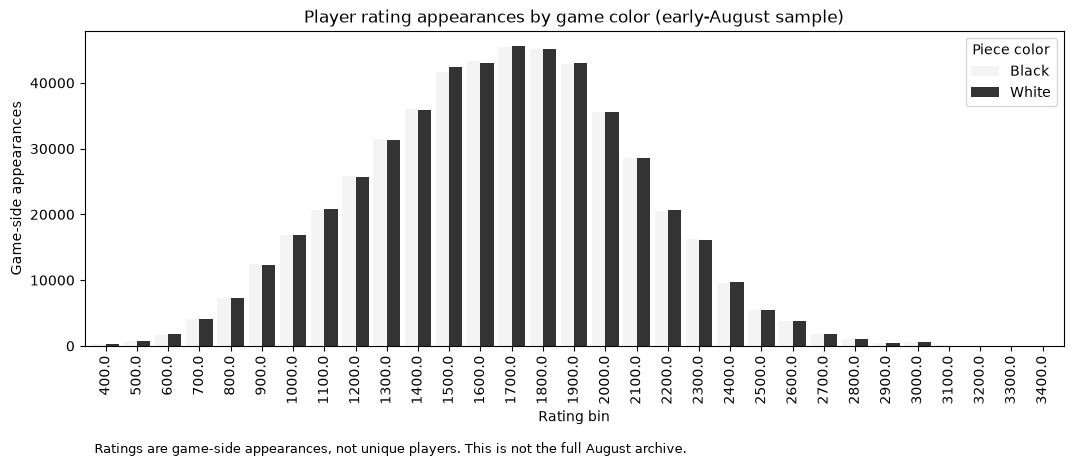

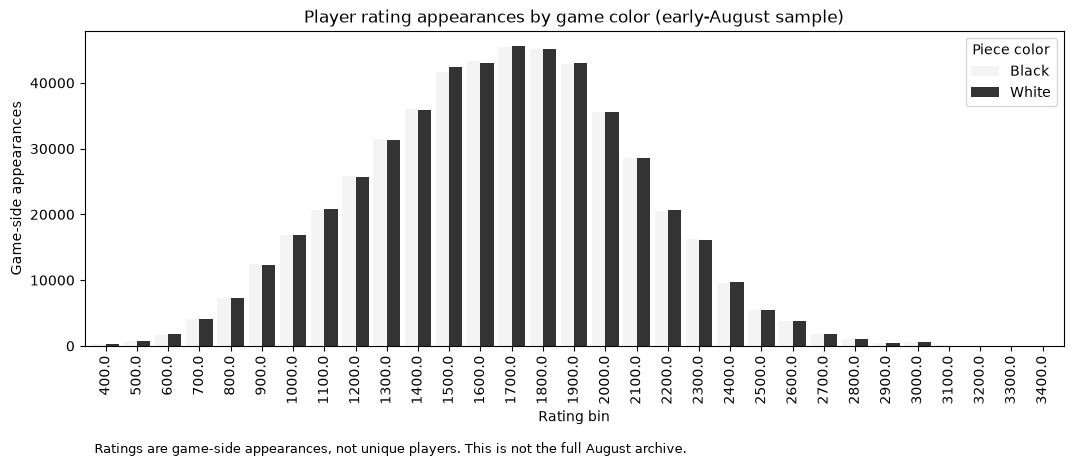

In [3]:
from IPython.display import display
rating_figure, rating_bins = rating_distribution_chart()
display(rating_figure)

The peak band is 1700-1799 for both colors: 45,630 White appearances and 45,463 Black appearances. These are game-side appearances, not unique players. The early-August sample does not represent the whole month.

## Chart 2 - Observed upset rate by rating-gap band
Among eligible games, how does the observed lower-rated-player win rate vary with the pre-game rating gap?

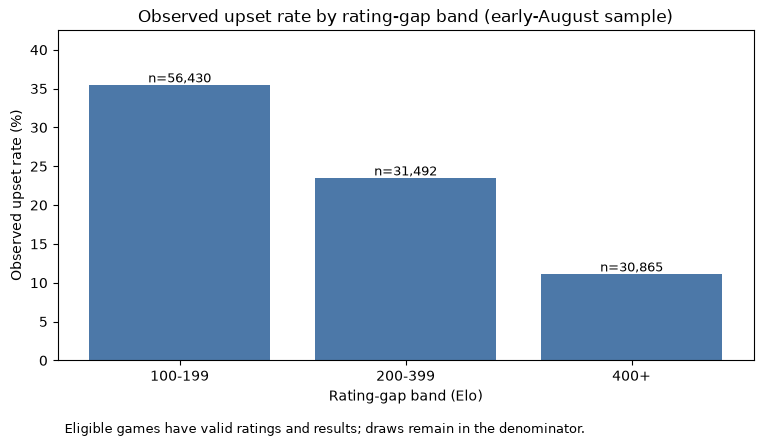

,rating_gap_band,eligible_games,upsets,upset_rate_pct
0,100-199,56430,19984.0,35.41
1,200-399,31492,7380.0,23.43
2,400+,30865,3415.0,11.06


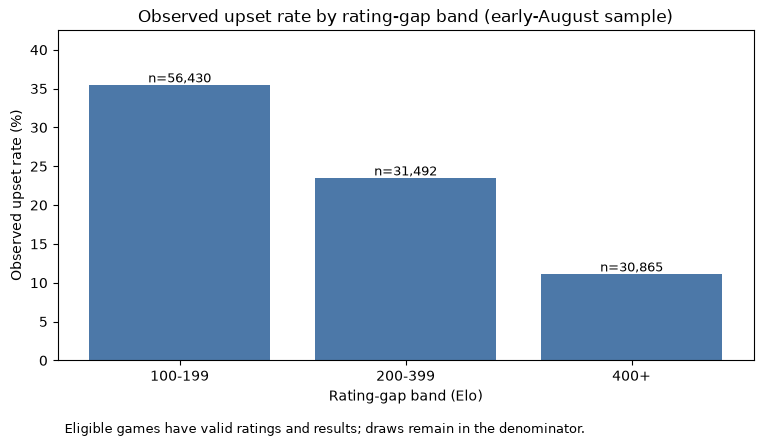

In [4]:
upset_figure, upset_bands = upset_rate_by_gap_chart()
display(upset_figure)
upset_bands.assign(upset_rate_pct=upset_bands['upset_rate_pct'].round(2))

The calculated table and chart describe eligible games in this early-August sample. They are observed rates, not universal upset probabilities; draws remain in each band denominator.

## Chart 3 - Game-result distribution by speed category
How do observed White wins, Black wins, and draws differ across the recorded game-speed categories?

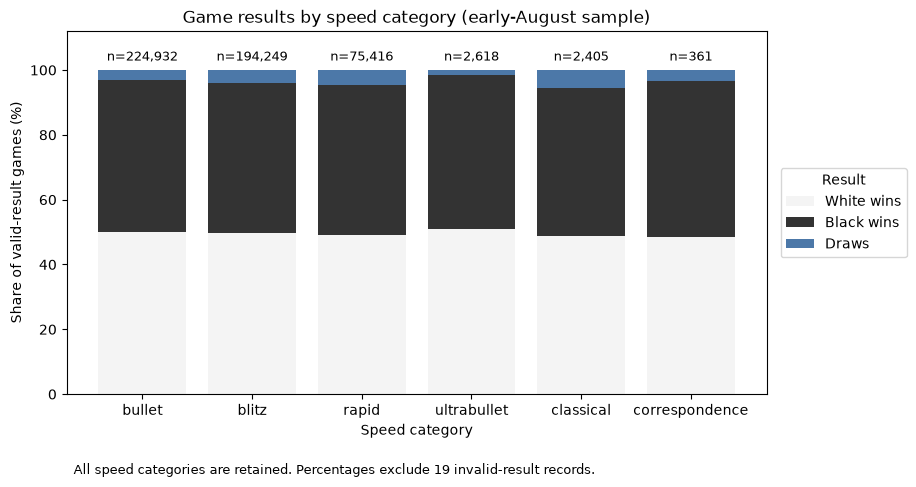

,speed_category,valid_games,white_wins,black_wins,draws,white_win_pct,black_win_pct,draw_pct
0,bullet,224932,112521.0,105490.0,6921.0,50.02,46.90,3.08
1,blitz,194249,96633.0,89912.0,7704.0,49.75,46.29,3.97
2,rapid,75416,37079.0,34862.0,3475.0,49.17,46.23,4.61
3,ultrabullet,2618,1336.0,1244.0,38.0,51.03,47.52,1.45
4,classical,2405,1172.0,1103.0,130.0,48.73,45.86,5.41
5,correspondence,361,175.0,174.0,12.0,48.48,48.20,3.32


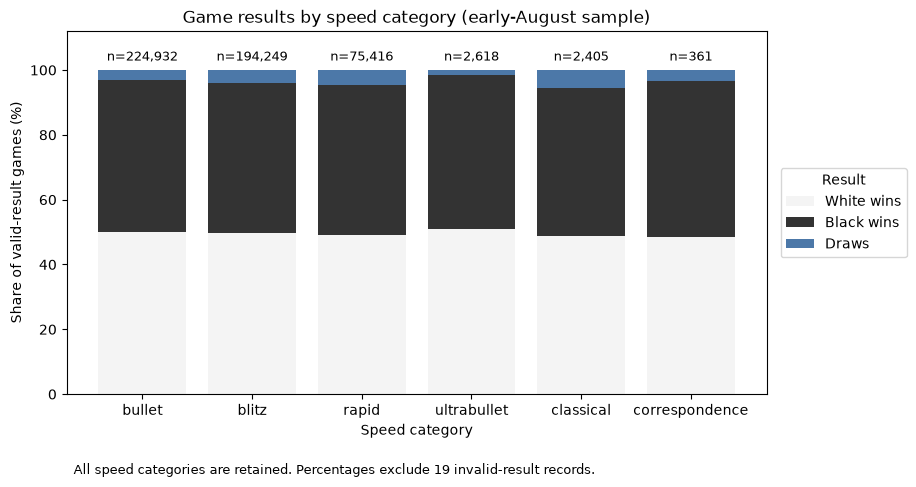

In [5]:
speed_figure, speed_results = result_distribution_by_speed_chart()
display(speed_figure)
speed_results.assign(white_win_pct=speed_results['white_win_pct'].round(2), black_win_pct=speed_results['black_win_pct'].round(2), draw_pct=speed_results['draw_pct'].round(2))

The chart retains every recorded speed category, including the small correspondence sample. These descriptive differences are associations in the early-August sample, not causal effects of time control.

## Limitations
No causal claims, charts, or Power BI work are included in Stage 1.